In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
chips = ['MICROCHIP_TRIANGLE', 'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in chips or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,MICROCHIP_TRIANGLE,9996,5,9995,9,,,10004,5,10005,9,,,10000.0,0.0
1,2,0,MICROCHIP_SQUARE,9996,5,9995,9,,,10004,5,10005,9,,,10000.0,0.0
2,2,0,MICROCHIP_RECTANGLE,9996,5,9995,9,,,10004,5,10005,9,,,10000.0,0.0
3,2,0,MICROCHIP_CIRCLE,9996,5,9995,9,,,10004,5,10005,9,,,10000.0,0.0
4,2,0,MICROCHIP_OVAL,9996,5,9995,9,,,10004,5,10005,9,,,10000.0,0.0


In [3]:
shapes = [s.split('_')[1] for s in chips]
chips, shapes

(['MICROCHIP_TRIANGLE',
  'MICROCHIP_CIRCLE',
  'MICROCHIP_OVAL',
  'MICROCHIP_RECTANGLE',
  'MICROCHIP_SQUARE'],
 ['TRIANGLE', 'CIRCLE', 'OVAL', 'RECTANGLE', 'SQUARE'])

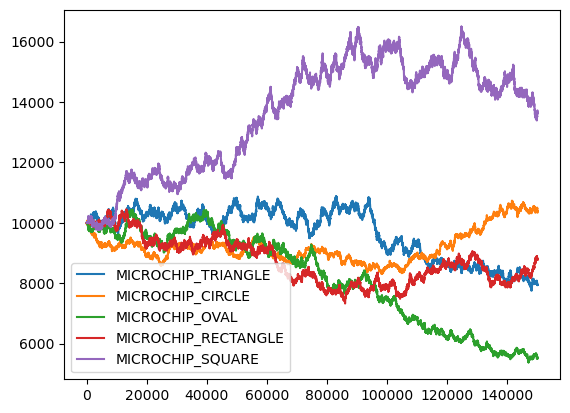

In [4]:
for p in chips:

    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

Circle - Oval

Square - Rectangle

In [5]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

<Axes: title={'center': 'Average mid across all PEBBLES'}, xlabel='timestamp'>

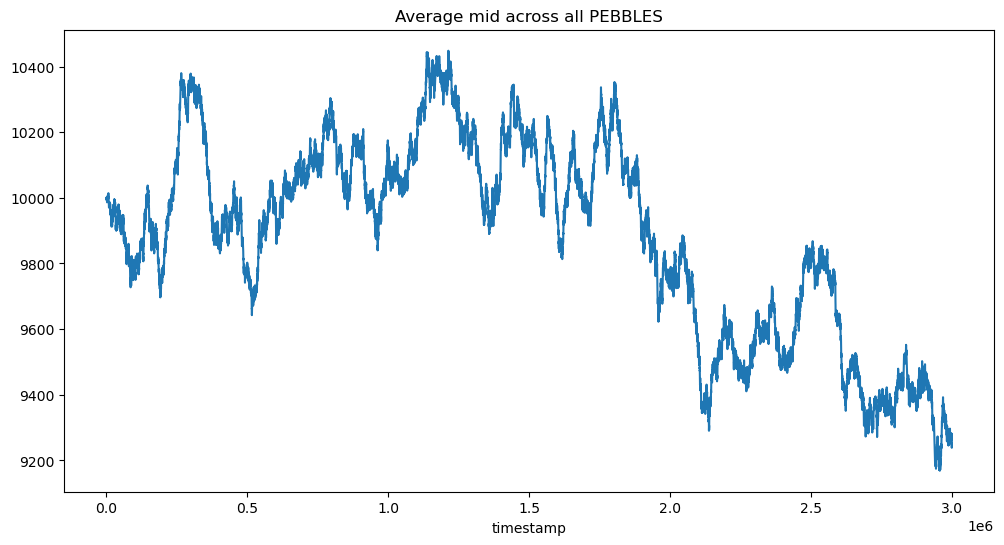

In [6]:
pebble_cols = [c for c in mids.columns]
mids["PEBBLES_avg"] = mids[pebble_cols].mean(axis=1)

mids["PEBBLES_avg"].plot(figsize=(12, 6), title="Average mid across all PEBBLES")

Just visually, it looks like the MICROCHIP_OVAL price might be the MICROCHIP_TRIANGLE price but just shifted backwards and also with a constant slope subtracted from it.

In [7]:
chip = lambda s: prices[prices['product'] == f'MICROCHIP_{s}']
ts_oval = LinearRegression()
ts_oval.fit(chip('OVAL')[['timestamp']], chip('OVAL').mid_price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


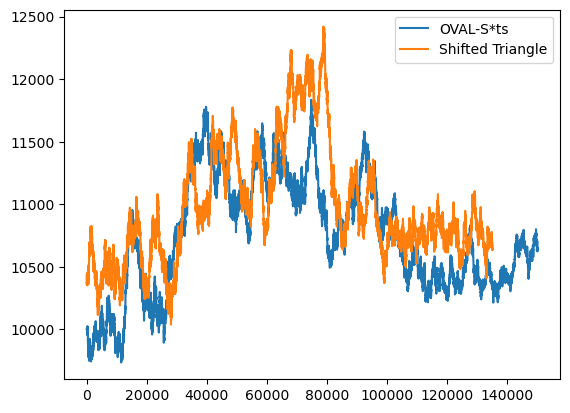

In [8]:
plt.plot(chip('OVAL').mid_price - ts_oval.coef_[0] * chip('OVAL').timestamp, label="OVAL-S*ts")
plt.plot(chip('TRIANGLE').mid_price.shift(-3000) + (chip('TRIANGLE').timestamp)*0.0010, label="Shifted Triangle")
plt.legend()
plt.show()

It seems like these are correlated heavily but not quite the same. The triangle mid price is more volatile. I don't know if this can be turned into a trading strategy.

Let's see if I can find something else

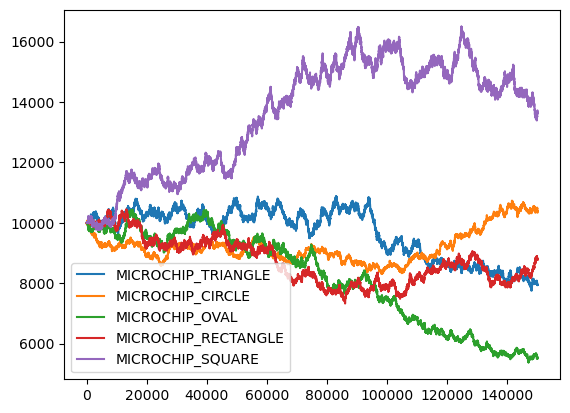

In [9]:
for p in chips:
    if p in chips:
        plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [10]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

pairs:   0%|          | 0/25 [00:00<?, ?it/s]

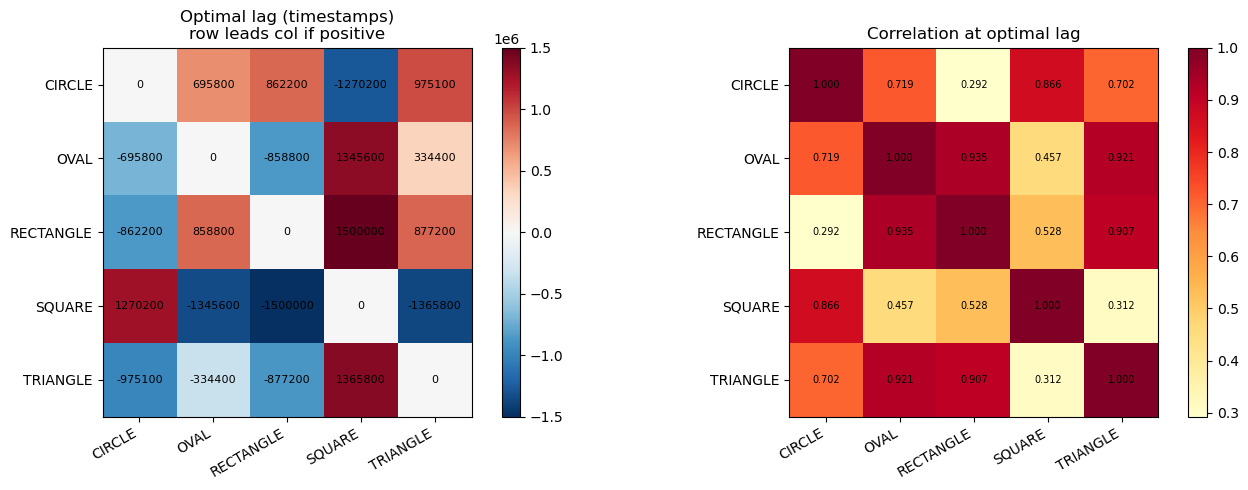

Timestamp step: 100 | Searching +/-1500000 ts = +/-15000 array shifts per pair

Pairwise optimal lead-lag summary (row LEADS col by N timestamps):
  CIRCLE vs OVAL: lag=+695800 ts  corr=0.7194  -> CIRCLE leads OVAL by 695800 ts
  CIRCLE vs RECTANGLE: lag=+862200 ts  corr=0.2924  -> CIRCLE leads RECTANGLE by 862200 ts
  CIRCLE vs SQUARE: lag=-1270200 ts  corr=0.8663  -> SQUARE leads CIRCLE by 1270200 ts
  CIRCLE vs TRIANGLE: lag=+975100 ts  corr=0.7025  -> CIRCLE leads TRIANGLE by 975100 ts
  OVAL vs RECTANGLE: lag=-858800 ts  corr=0.9347  -> RECTANGLE leads OVAL by 858800 ts
  OVAL vs SQUARE: lag=+1345600 ts  corr=0.4572  -> OVAL leads SQUARE by 1345600 ts
  OVAL vs TRIANGLE: lag=+334400 ts  corr=0.9215  -> OVAL leads TRIANGLE by 334400 ts
  RECTANGLE vs SQUARE: lag=+1500000 ts  corr=0.5277  -> RECTANGLE leads SQUARE by 1500000 ts
  RECTANGLE vs TRIANGLE: lag=+877200 ts  corr=0.9068  -> RECTANGLE leads TRIANGLE by 877200 ts
  SQUARE vs TRIANGLE: lag=-1365800 ts  corr=0.3124  -> TRIANGL

In [11]:
from tqdm.auto import tqdm

# Pairwise optimal lead-lag analysis
# For each pair (A, B), find the lag L that maximizes corr(A[t], B[t+L])
# Positive L means A leads B (B lags behind A)

MAX_LAG_TS = 1_500_000  # max lag in timestamp units

sleep_cols = [c for c in mids.columns if c.startswith("MICROCHIP")]
filled = mids[sleep_cols].ffill()

ts_step = int(filled.index[1] - filled.index[0])   # 100: one array shift = 100 ts units
max_lag_idx = MAX_LAG_TS // ts_step                 # number of array positions to sweep

lag_idxs = np.arange(-max_lag_idx, max_lag_idx + 1)
n = len(sleep_cols)
opt_lag = np.zeros((n, n), dtype=int)
opt_corr = np.zeros((n, n))

pairs = [(i, a, j, b) for i, a in enumerate(sleep_cols) for j, b in enumerate(sleep_cols)]
for i, a, j, b in tqdm(pairs, desc="pairs"):
    if i == j:
        opt_lag[i, j] = 0
        opt_corr[i, j] = 1.0
        continue
    sa = filled[a].values
    sb = filled[b].values
    xcorr = np.array([
        np.corrcoef(sa[:len(sa)-abs(l)], sb[abs(l):])[0, 1] if l >= 0
        else np.corrcoef(sa[abs(l):], sb[:len(sb)-abs(l)])[0, 1]
        for l in lag_idxs
    ])
    best = np.argmax(xcorr)
    opt_lag[i, j] = lag_idxs[best] * ts_step   # report in timestamp units
    opt_corr[i, j] = xcorr[best]

short_names = [c.replace("MICROCHIP_", "") for c in sleep_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(opt_lag, cmap="RdBu_r", vmin=-MAX_LAG_TS, vmax=MAX_LAG_TS)
axes[0].set_title("Optimal lag (timestamps)\nrow leads col if positive")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(short_names, rotation=30, ha="right")
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, opt_lag[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im0, ax=axes[0])

# Use actual data min so the full range of variation is visible
corr_min = opt_corr.min()
im1 = axes[1].imshow(opt_corr, cmap="YlOrRd", vmin=corr_min, vmax=1.0)
axes[1].set_title("Correlation at optimal lag")
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(short_names, rotation=30, ha="right")
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f"{opt_corr[i, j]:.3f}", ha="center", va="center", fontsize=7)
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Timestamp step: {ts_step} | Searching +/-{MAX_LAG_TS} ts = +/-{max_lag_idx} array shifts per pair")
print("\nPairwise optimal lead-lag summary (row LEADS col by N timestamps):")
for i, a in enumerate(short_names):
    for j, b in enumerate(short_names):
        if i < j:
            lag = opt_lag[i, j]
            direction = f"{a} leads {b}" if lag > 0 else f"{b} leads {a}" if lag < 0 else "no lead"
            print(f"  {a} vs {b}: lag={lag:+d} ts  corr={opt_corr[i,j]:.4f}  -> {direction} by {abs(lag)} ts")

In [12]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from hurst import compute_Hc

assets = shapes
for asset in assets[4:5]:
    tmp = chip(asset).mid_price
    log_returns = np.diff(np.log(tmp))
    diff = np.diff(tmp)
    
    # GBM in log space should be iid Gaussian
    print(f"Asset {asset}:")
    print(f"  ADF on levels: {adfuller(tmp)[1]:.4f}")  # should NOT reject
    print(f"  ADF on log-returns: {adfuller(log_returns)[1]:.4f}")  # should reject
    print(f"  Ljung-Box on log-returns:\n {acorr_ljungbox(log_returns, lags=5)}")  # should be white noise
    print(f"  Hurst: {compute_Hc(tmp)}")  # should be ~0.5
    print(f"  Skewness of log-returns: {stats.skew(log_returns):.4f}")
    print(f"  Excess kurtosis of log-returns: {stats.kurtosis(log_returns):.4f}")

Asset SQUARE:
  ADF on levels: 0.3017
  ADF on log-returns: 0.0000
  Ljung-Box on log-returns:
      lb_stat  lb_pvalue
1  14.532009   0.000138
2  16.737631   0.000232
3  17.682719   0.000511
4  19.638416   0.000589
5  20.484086   0.001013
  Hurst: (np.float64(0.5548353030623312), np.float64(1.1023543188025837), [[10, 17, 31, 56, 100, 177, 316, 562, 1000, 1778, 3162, 5623, 10000, 17782, 30000], [np.float64(3.9468384834480634), np.float64(5.448113725949789), np.float64(7.65324553019085), np.float64(10.520894345208678), np.float64(14.548301966753018), np.float64(19.491789048303183), np.float64(26.26174557851402), np.float64(35.81144981069833), np.float64(49.12216980926885), np.float64(67.36627474601448), np.float64(92.96597083309324), np.float64(118.91971898787395), np.float64(164.02852890463137), np.float64(343.250188011006), np.float64(325.5901444162895)]])
  Skewness of log-returns: 0.0020
  Excess kurtosis of log-returns: 0.0388


# Some notes on the test results
TRIANGLE. : Definitely a GBM -- has all the telltale signs  
SQUARE.   : Momentum (maybe AR(1)?) process. Does not pass the tests for GBM  
RECTANGLE : Definitely a GBM  
CIRCLE    : Essentially GBM but one of the p-values is just above 5%  
OVAL      : Ambiguous -- perhaps long range momentum  
All have stationary increments  
Now let's test the cross-asset correlations.  

           TRIANGLE    CIRCLE      OVAL  RECTANGLE    SQUARE
TRIANGLE   1.000000  0.003034  0.001770   0.005318  0.007537
CIRCLE     0.003034  1.000000  0.012625   0.010187  0.007556
OVAL       0.001770  0.012625  1.000000   0.002543  0.004913
RECTANGLE  0.005318  0.010187  0.002543   1.000000  0.006165
SQUARE     0.007537  0.007556  0.004913   0.006165  1.000000
Bartlett sphericity: chi2=14.4653, p=0.1528


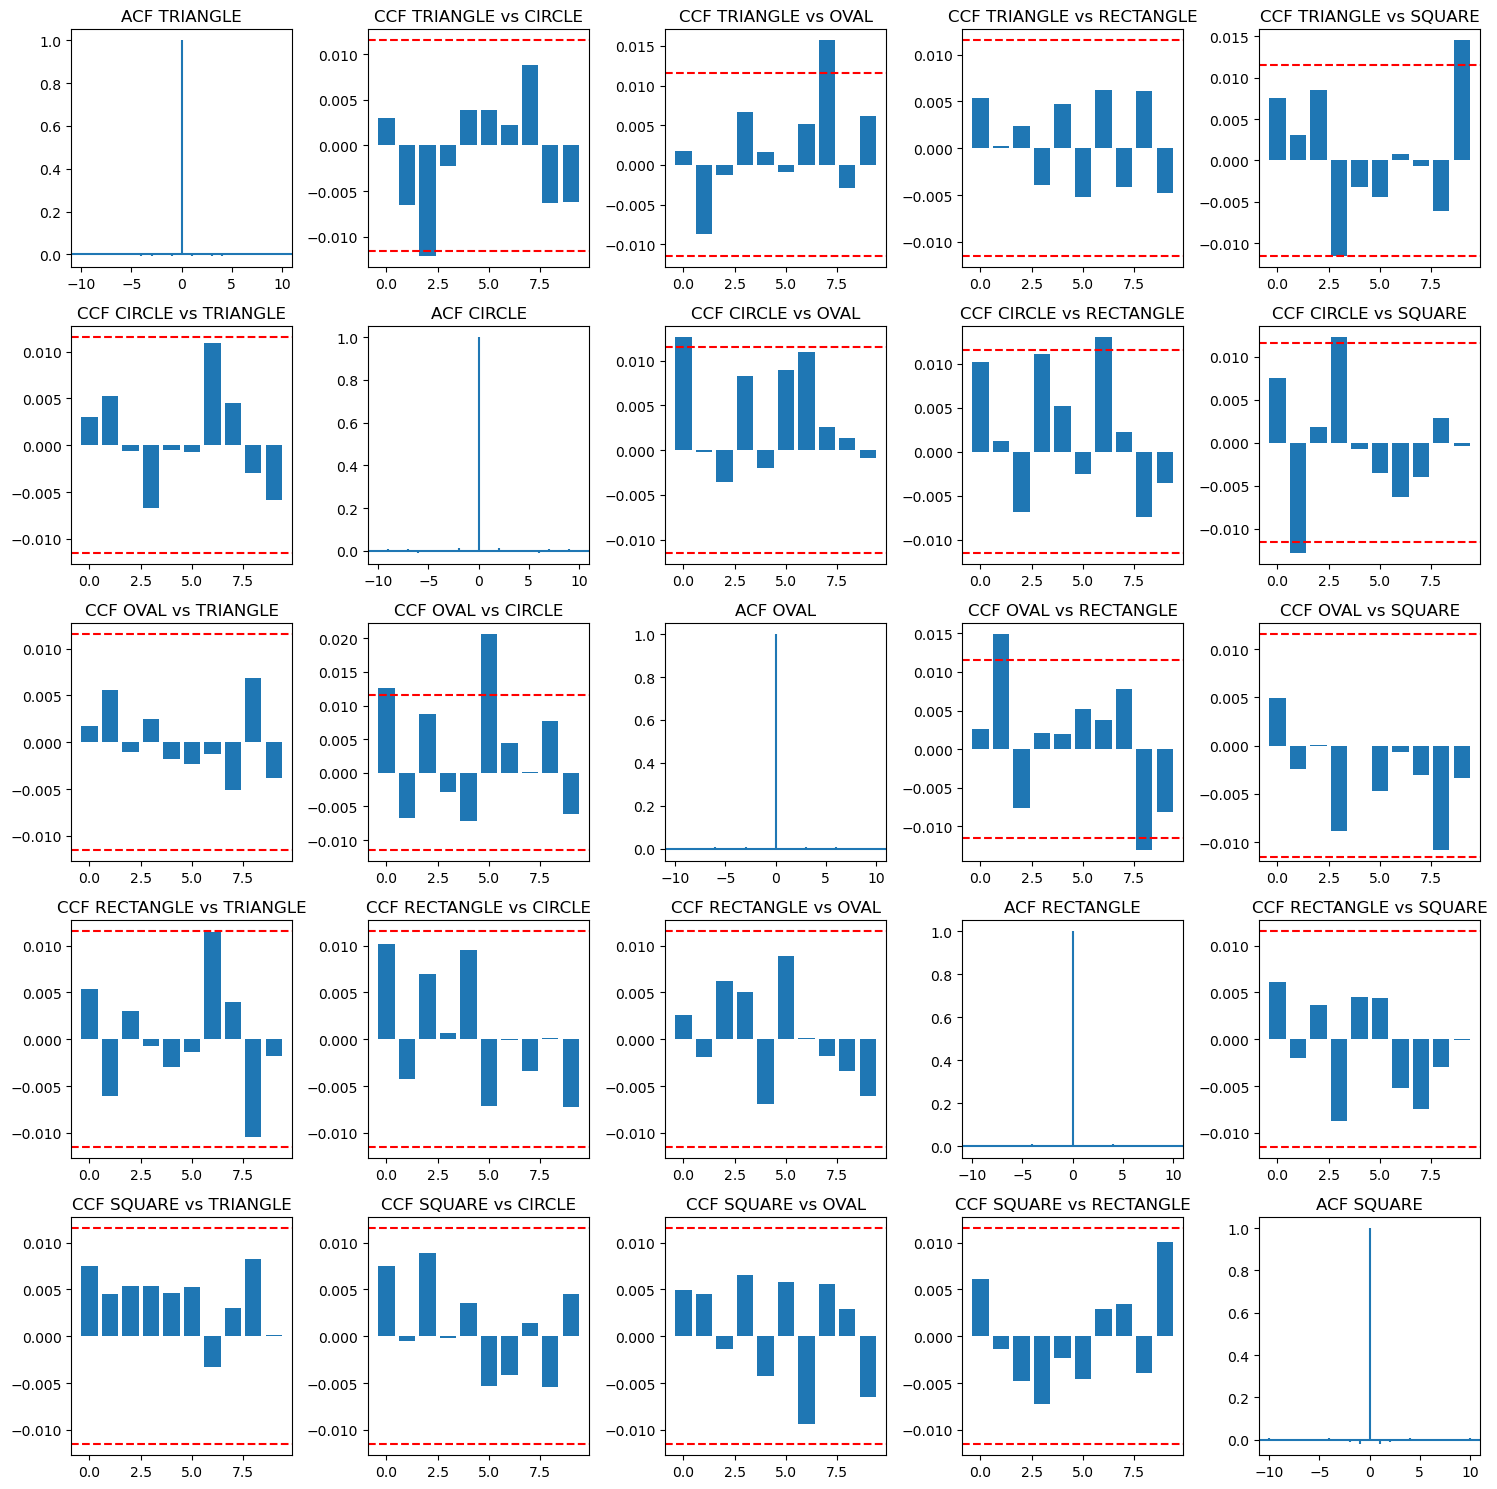

In [13]:
import numpy as np
from scipy import stats
import pandas as pd

# Compute difference (or log-return) series for each asset
diffs = {asset: np.diff(np.log(chip(asset).mid_price)) for asset in assets}
diff_df = pd.DataFrame(diffs)

# 1. Contemporaneous correlation matrix
corr_matrix = diff_df.corr()
print(corr_matrix)

# 2. Test if correlation matrix is significantly different from identity
# Using the Bartlett sphericity test
n = len(diff_df)
p = len(assets)
det = np.linalg.det(corr_matrix.values)
chi2_stat = -(n - 1 - (2*p + 5)/6) * np.log(det)
dof = p * (p - 1) / 2
p_value = 1 - stats.chi2.cdf(chi2_stat, dof)
print(f"Bartlett sphericity: chi2={chi2_stat:.4f}, p={p_value:.4f}")
# p << 0.05 means correlations are significant -> NOT independent

# 3. Check cross-correlations at multiple lags
from statsmodels.tsa.stattools import ccf

fig, axes = plt.subplots(p, p, figsize=(15, 15))
for i, a1 in enumerate(assets):
    for j, a2 in enumerate(assets):
        if i == j:
            axes[i,j].acorr(diffs[a1], maxlags=10)
            axes[i,j].set_title(f'ACF {a1}')
        else:
            cc = ccf(diffs[a1], diffs[a2], nlags=10)
            axes[i,j].bar(range(len(cc)), cc)
            axes[i,j].axhline(2/np.sqrt(n), color='r', linestyle='--')
            axes[i,j].axhline(-2/np.sqrt(n), color='r', linestyle='--')
            axes[i,j].set_title(f'CCF {a1} vs {a2}')

plt.tight_layout()
plt.show()

## Nothing to see here folks
It seems like these aren't really that well-correlated with each other. Even though there are ones that are statistically significant, their correlation magnitude is basically 0 (the confidence band is very small due to large n). There is also the problem of multiple hypothesis testing -- there are bound to be some false positives even if they are independent just because we set the type 1 error rate to 0.05 (so 1 in every 20 tests should be a false positive in expectation. Here we have ~12 positives).

So for the time being I will assume that these are all independent and everything except SQUARE is a GBM. Let's fit a model for SQUARE

In [14]:
from statsmodels.tsa.ar_model import AutoReg

log_ret = np.diff(np.log(chip('SQUARE').mid_price))  # or whichever asset it was

# Fit AR(1) on log-returns
model = AutoReg(log_ret, lags=1).fit()
print(model.summary())

phi1 = model.params[1]  # AR(1) coefficient - expect small positive value
intercept = model.params[0]  # drift term
sigma = np.std(model.resid, ddof=2)

print(f"phi1: {phi1:.4f}")
print(f"intercept: {intercept:.4f}")
print(f"sigma: {sigma:.4f}")

# Then run your residual diagnostics
# Ljung-Box on residuals should now pass

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                29999
Model:                     AutoReg(1)   Log Likelihood              152341.827
Method:               Conditional MLE   S.D. of innovations              0.002
Date:                Wed, 29 Apr 2026   AIC                        -304677.655
Time:                        19:18:08   BIC                        -304652.728
Sample:                             1   HQIC                       -304669.657
                                29999                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.056e-05    8.7e-06      1.213      0.225    -6.5e-06    2.76e-05
y.L1          -0.0220      0.006     -3.813      0.000      -0.033      -0.011
                                    Roots           

### This ain't it
This model is quite shit. Nothing is really statistically significant.
I could try to fit a long-term autocorrelation model but I think that's not really worth our time tbh

In [15]:
import numpy as np

def estimate_gbm_params(prices, dt=1.0):
    """
    prices: price level series
    dt: time step size (1.0 if returns are already per-tick)
    """
    log_ret = np.diff(np.log(prices))
    n = len(log_ret)
    
    # MLE estimates
    mu_ret = np.mean(log_ret)       # mean log-return per tick
    sigma2 = np.var(log_ret, ddof=1) # variance of log-returns
    sigma = np.sqrt(sigma2 / dt)     # volatility per unit time
    
    # Drift of the price process (Ito correction)
    mu = mu_ret / dt + 0.5 * sigma2 / dt  # drift of S, not log(S)
    
    # Standard errors
    se_mu_ret = np.sqrt(sigma2 / n)
    se_sigma = sigma / np.sqrt(2 * (n-1))
    
    # t-stat for drift being nonzero
    t_stat = mu_ret / se_mu_ret
    
    return {
        'mu_log': mu_ret,        # mean log-return per tick
        'mu': mu,                # drift of price process
        'sigma': sigma,          # volatility
        'se_mu': se_mu_ret,      # std error of mean log-return
        'se_sigma': se_sigma,    # std error of sigma
        't_stat_drift': t_stat,  # is drift significantly nonzero?
    }

for asset in shapes:
    params = estimate_gbm_params(chip(asset).mid_price)
    print(f"{asset}: mu_log={params['mu_log']:.6f} "
          f"(t={params['t_stat_drift']:.2f}) "
          f"sigma={params['sigma']:.6f}")

TRIANGLE: mu_log=-0.000008 (t=-0.89) sigma=0.001491
CIRCLE: mu_log=0.000001 (t=0.22) sigma=0.000999
OVAL: mu_log=-0.000020 (t=-2.29) sigma=0.001499
RECTANGLE: mu_log=-0.000004 (t=-0.50) sigma=0.001499
SQUARE: mu_log=0.000010 (t=1.19) sigma=0.001508


# Conclusion
It looks like the only exploitable thing here is to go short on OVAL at the max position limit. They don't seem to be lags of each other or correlated otherwise. They are mostly GBMs with drifts so small that they're not statistically significant except OVAL.

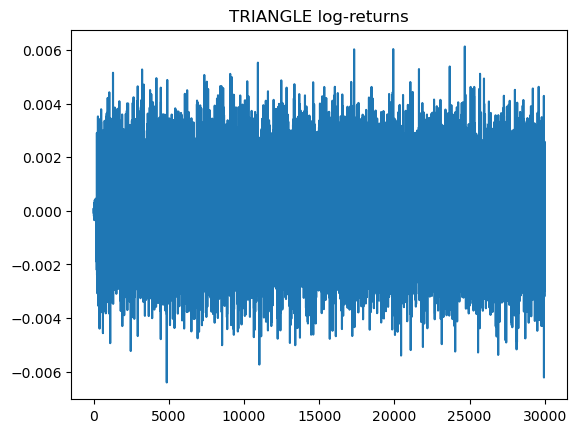

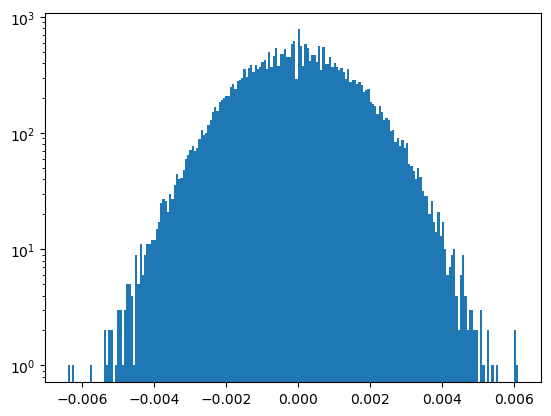

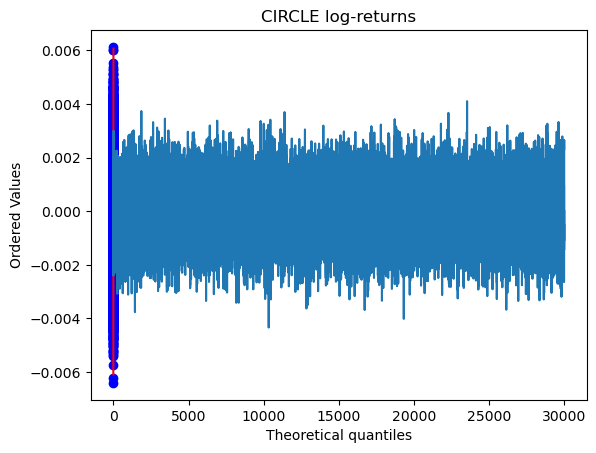

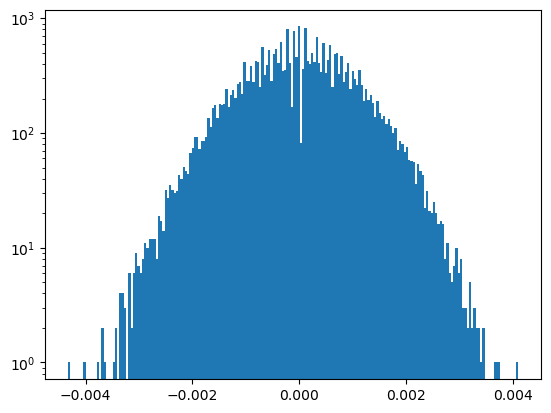

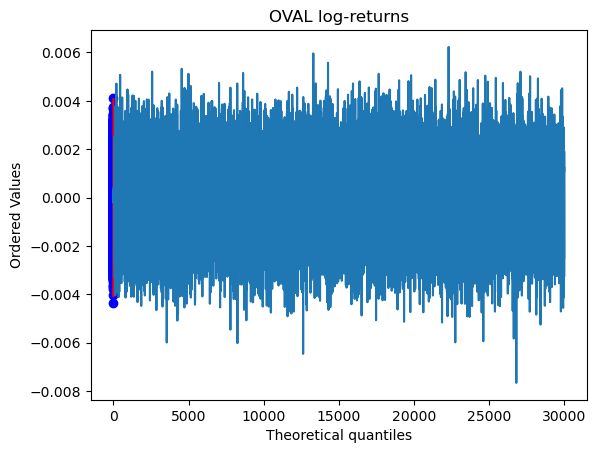

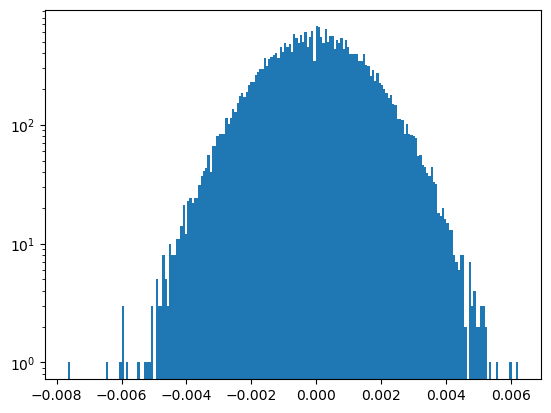

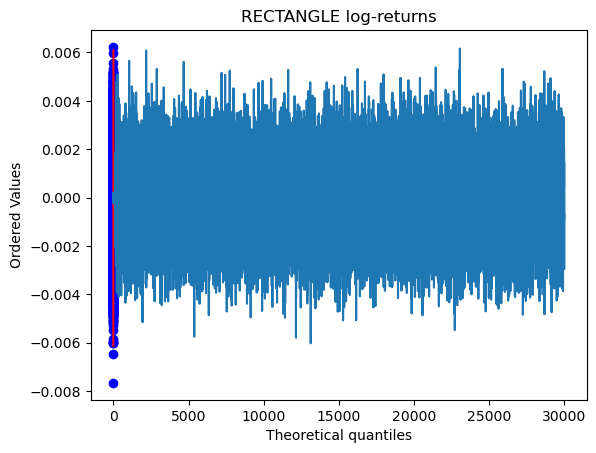

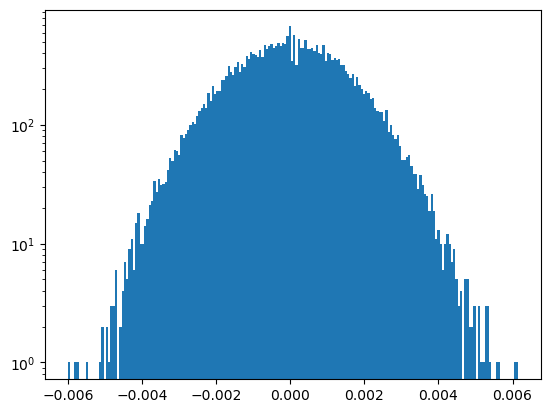

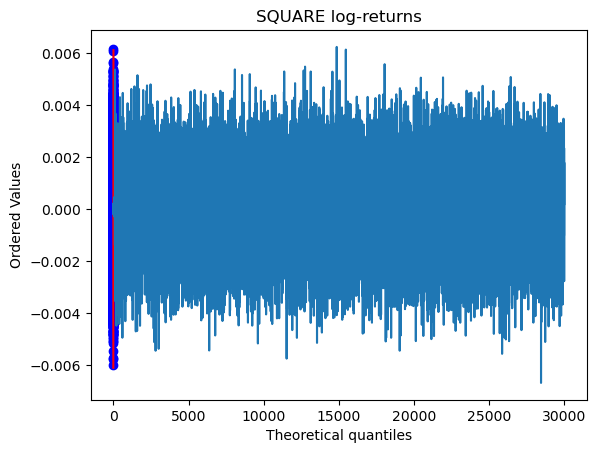

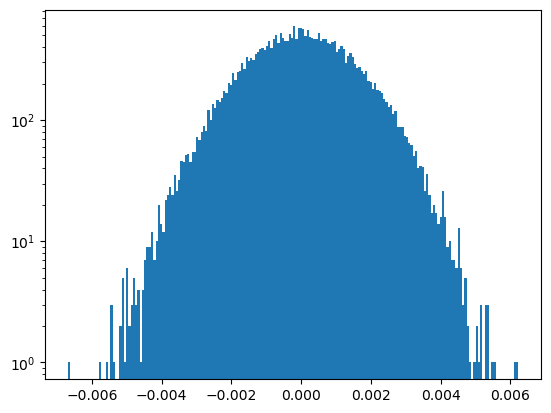

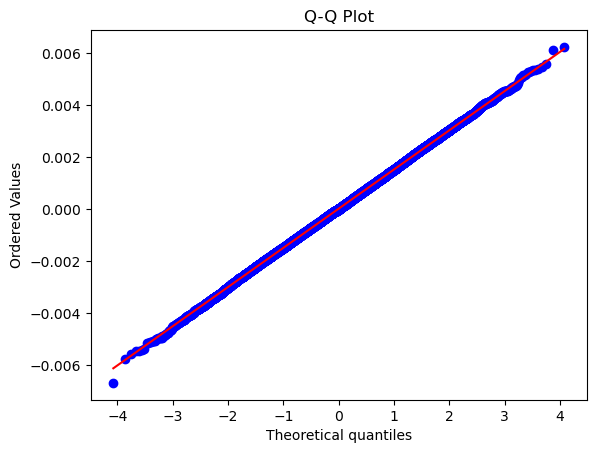

In [18]:
for s in shapes:
    log_ret = np.diff(np.log(chip(s).mid_price))
    plt.plot(log_ret)
    plt.title(f'{s} log-returns')
    plt.show()
    # Also look at the distribution
    plt.hist(log_ret, bins=200)
    plt.yscale('log')  # log scale to see tail behavior
    plt.show()
    stats.probplot(log_ret, dist="norm", plot=plt)
    plt.title('Q-Q Plot')

In [17]:
from statsmodels.tsa.stattools import coint
import itertools

for a1, a2 in itertools.combinations(chips, 2):
    pval = coint(mids[a1], mids[a2])[1]
    print(f"{a1} vs {a2}: p={pval:.4f}")
    # p < 0.05 means cointegrated → pairs trade

MICROCHIP_TRIANGLE vs MICROCHIP_CIRCLE: p=0.3508
MICROCHIP_TRIANGLE vs MICROCHIP_OVAL: p=0.0526
MICROCHIP_TRIANGLE vs MICROCHIP_RECTANGLE: p=0.9121
MICROCHIP_TRIANGLE vs MICROCHIP_SQUARE: p=0.8959
MICROCHIP_CIRCLE vs MICROCHIP_OVAL: p=0.5413
MICROCHIP_CIRCLE vs MICROCHIP_RECTANGLE: p=0.9136
MICROCHIP_CIRCLE vs MICROCHIP_SQUARE: p=0.9145
MICROCHIP_OVAL vs MICROCHIP_RECTANGLE: p=0.9431
MICROCHIP_OVAL vs MICROCHIP_SQUARE: p=0.9707
MICROCHIP_RECTANGLE vs MICROCHIP_SQUARE: p=0.0196


According to the test above, we have statistical evidence of the following cointegrations
- RECTANGLE VS SQUARE
- POSSIBLY ALSO TRIANGLE VS OVAL (the p-value is just over 5%)

no triples show cointegration signs